# Natural Language Processing
## Assignment 1 - Group 17

*_Adriano Machado (up202105352), Félix Martins (up202108837), Francisco da Ana (up202108762)_*  


### Overview
This assignment applies fundamental NLP techniques to solve a text classification problem without relying on deep learning architectures.

This notebook follows the following workflow:

1. **Data Exploration**: Understanding the dataset's characteristics through visualizations and statistical analysis
2. **Pre-processing Pipeline**: Implementing text normalization, cleaning, and feature extraction
3. **Feature Representation**: Experimenting with both sparse (e.g., TF-IDF) and dense (e.g., word embeddings) representations
4. **Model Selection**: Testing various classical ML algorithms (Naive Bayes, Logistic Regression, SVM, etc.)
5. **Evaluation & Refinement**: Measuring performance, analyzing errors, and iteratively improving the models


## Data Provenance and Characteristics

The [Polite Guard dataset](https://github.com/intel/polite-guard) is a specialized corpus developed by Intel for **politeness classification** in text. This dataset serves as the foundation for our NLP classification task.

### Data Sources and Collection

The dataset comprises three distinct components:
- **50,000 samples** generated using Few-Shot prompting
- **50,000 samples** generated using Chain-of-Thought (CoT) prompting
- **200 annotated samples** from corporate trainings (with personal identifiers removed)

The dataset is primarily synthetic, created using large language models (LLMs) to simulate customer service interactions across various sectors, such as finance, travel, food and drink, sports, etc. 


### Annotation Process

The dataset features a four-category classification system:
1. **Polite**: Text showing consideration, respect, and good manners with courteous phrases and friendly tone
2. **Somewhat Polite**: Generally respectful text lacking warmth or formality but maintaining a decent level of courtesy
3. **Neutral**: Straightforward and factual text without emotional undertones or specific attempts at politeness
4. **Impolite**: Disrespectful or rude text, often blunt or dismissive, showing lack of consideration


### Data Generation Process
- **Synthetic Data**: Generated through language models (Llama 3.1 8B-Instruct, Gemma 2 9B-It, Mixtral 8x7B-Instruct-v0.1) with specific instructions to create text matching the desired politeness category
- **Real Data**: The 200 real-world samples were collected from corporate trainings and manually annotated


### Data Distribution

The synthetic data is split into:
- Training set (80%)
- Validation set (10%)
- Test set (10%)

### Data Structure

Each example in the dataset contains:
- **text**: The input text string
- **label**: The classification label (polite, somewhat polite, neutral, impolite)
- **source**: The language model used for generation or "LMS" for corporate training samples
- **reasoning**: The rationale provided by the language model for the generated text (for synthetic samples)

## Exploratory Data Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from textblob import TextBlob

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/adriano/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/adriano/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
file_paths = {
    'train_cot': 'data/train/train_cot.csv',
    'train_few_shot': 'data/train/train_few_shot.csv',
    'val_cot': 'data/validation/val_cot.csv',
    'val_few_shot': 'data/validation/val_few_shot.csv',
    'test_cot': 'data/test/test_cot.csv',
    'test_few_shot': 'data/test/test_few_shot.csv',
    'test_LMs': 'data/test/test_lms.csv'
}

sns.set_palette("crest")

dataframes = {}
for name, path in file_paths.items():
    dataframes[name] = pd.read_csv(path)

In [15]:
for name, df in dataframes.items():
    shape_info = f"{name}: {df.shape} | Columns: {', '.join(df.columns)}"
    missing_info = f" | Missing Values: {df.isnull().sum().to_dict()}"
    
    duplicate_count = df.duplicated().sum()
    duplicates_info = f" | Duplicates: {duplicate_count}"
    
    print(shape_info)
    print(missing_info + duplicates_info)
    print()

train_cot: (40000, 4) | Columns: text, label, source, reasoning
 | Missing Values: {'text': 0, 'label': 0, 'source': 0, 'reasoning': 1} | Duplicates: 0

train_few_shot: (40000, 4) | Columns: text, label, source, reasoning
 | Missing Values: {'text': 0, 'label': 0, 'source': 0, 'reasoning': 40000} | Duplicates: 0

val_cot: (5000, 4) | Columns: text, label, source, reasoning
 | Missing Values: {'text': 0, 'label': 0, 'source': 0, 'reasoning': 0} | Duplicates: 0

val_few_shot: (5000, 4) | Columns: text, label, source, reasoning
 | Missing Values: {'text': 0, 'label': 0, 'source': 0, 'reasoning': 5000} | Duplicates: 0

test_cot: (5000, 4) | Columns: text, label, source, reasoning
 | Missing Values: {'text': 0, 'label': 0, 'source': 0, 'reasoning': 0} | Duplicates: 0

test_few_shot: (5000, 4) | Columns: text, label, source, reasoning
 | Missing Values: {'text': 0, 'label': 0, 'source': 0, 'reasoning': 5000} | Duplicates: 0

test_LMs: (200, 4) | Columns: text, label, source, reasoning
 | Mis

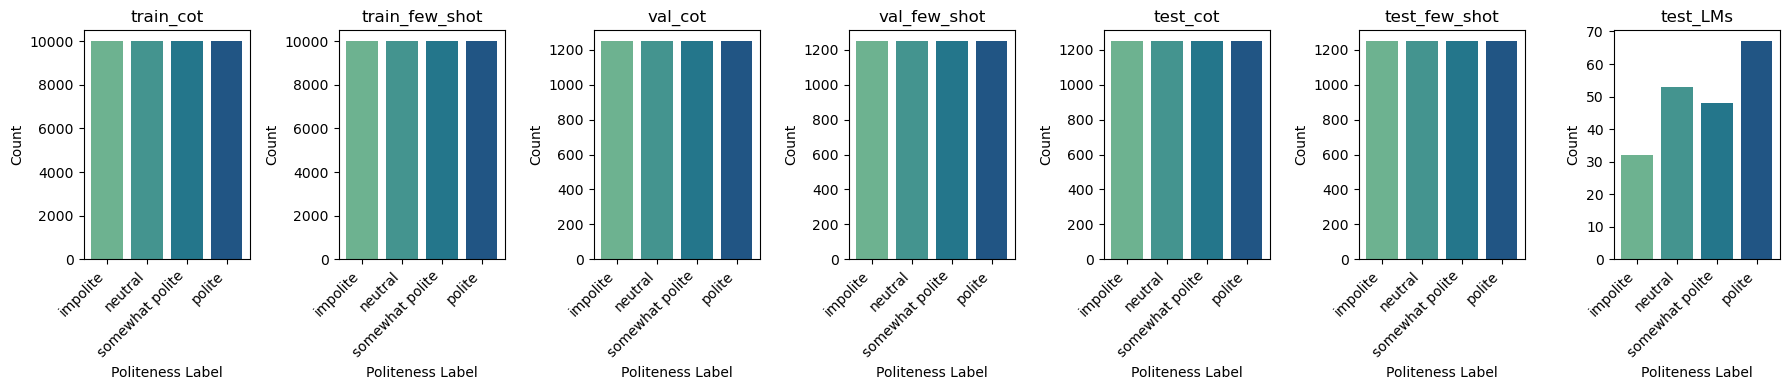

In [16]:
label_order = ['impolite', 'neutral', 'somewhat polite', 'polite']

plt.figure(figsize=(18, 4))
n_datasets = len(dataframes)
for i, (name, df) in enumerate(dataframes.items(), 1):
    if 'label' in df.columns:
        label_counts = Counter(df['label'].astype(str))
        labels = [l for l in label_order if l in label_counts]  
        counts = [label_counts[l] for l in labels if l in label_counts]
        
        plt.subplot(1, n_datasets, i)
        
        colors = sns.color_palette("crest", n_colors=len(labels))
        plt.bar(labels, counts, color=colors)
        
        plt.title(f'{name}')
        plt.xlabel('Politeness Label')
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
    
plt.tight_layout()
plt.show()

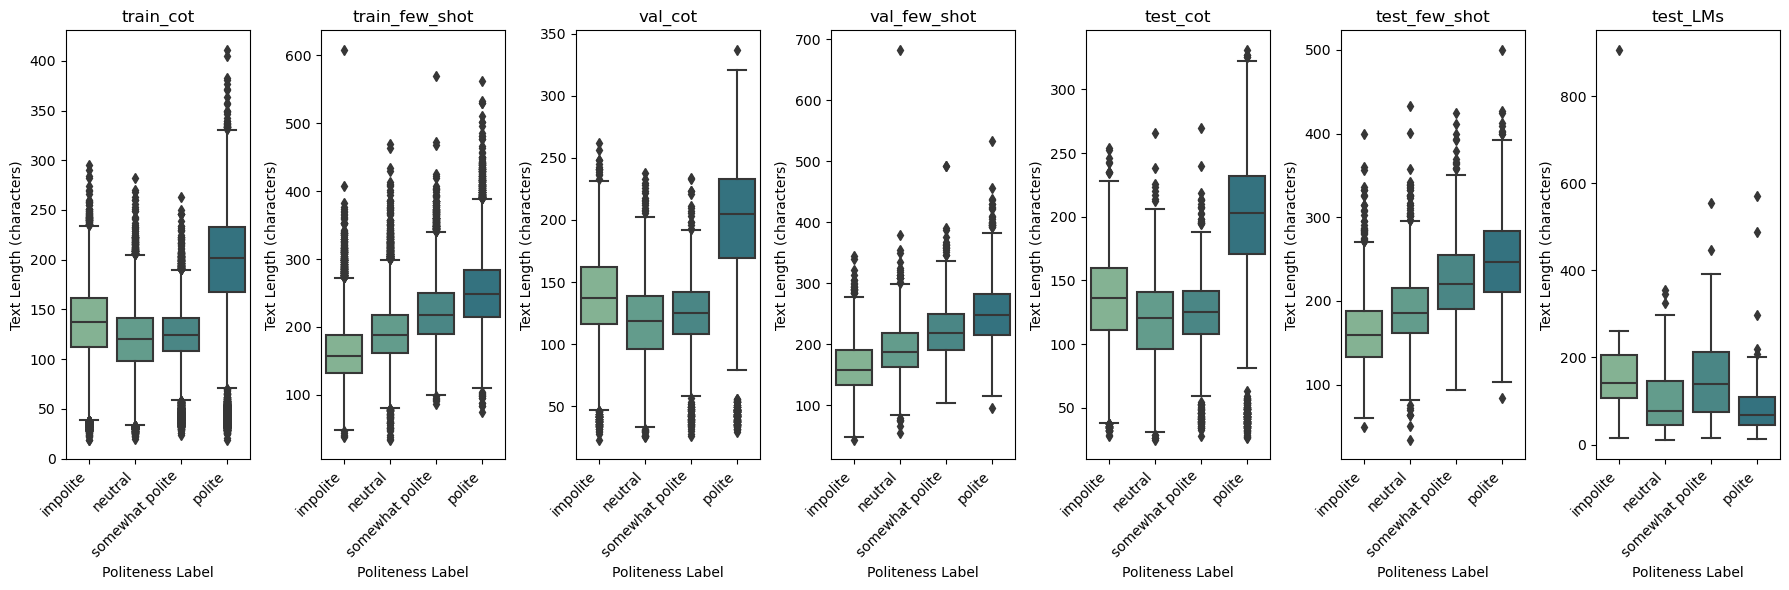

In [17]:
plt.figure(figsize=(18, 6))
for i, (name, df) in enumerate(dataframes.items(), 1):
    if 'label' in df.columns and 'text' in df.columns:
        text_lengths = df['text'].astype(str).fillna('').str.len()
        
        plt.subplot(1, n_datasets, i)
        sns.boxplot(data=df, x='label', y=text_lengths, order=label_order)
        plt.title(f'{name}')
        plt.xlabel('Politeness Label')
        plt.ylabel('Text Length (characters)')
        plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/adriano/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


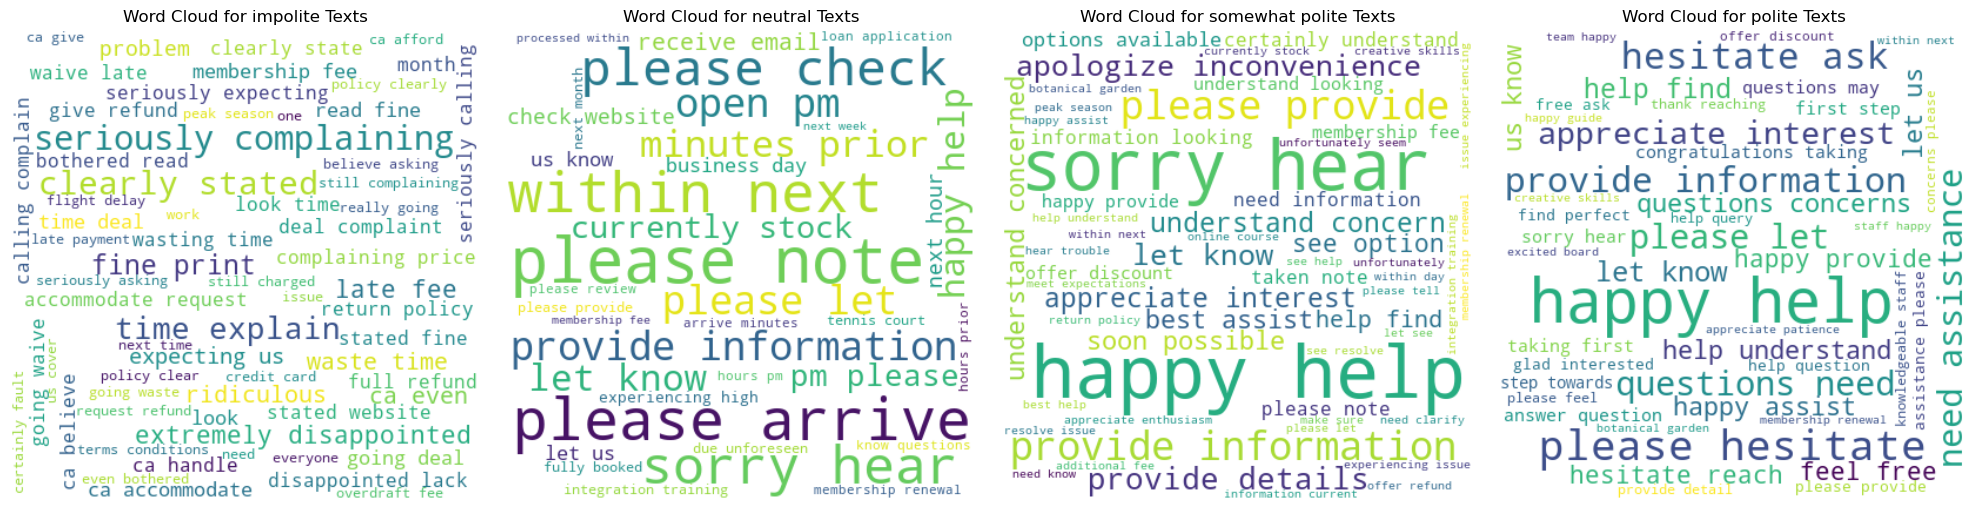

In [ ]:

def generate_word_clouds(label_texts, label_order):
    num_labels = len(label_order)
    fig, axes = plt.subplots(1, num_labels, figsize=(5 * num_labels, 5)) 
    
    if num_labels == 1: 
        axes = [axes]

    for ax, label in zip(axes, label_order):
        if label_texts[label]: 
            stop_words = set(stopwords.words('english'))
            word_tokens = word_tokenize(' '.join(label_texts[label]))
            filtered_words = [word.lower() for word in word_tokens if word.lower() not in stop_words and word.isalnum()]
            
            wordcloud = WordCloud(width=400, height=400, background_color='white', min_font_size=10).generate(' '.join(filtered_words))

            ax.imshow(wordcloud, interpolation='bilinear')
            ax.set_title(f'Word Cloud for {label} Texts')
            ax.axis('off')

    plt.tight_layout()
    plt.show()

label_texts = {label: [] for label in label_order}
for name, df in dataframes.items():
    if 'label' in df.columns and 'text' in df.columns:
        for label in label_order:
            label_texts[label].extend(df[df['label'].astype(str) == label]['text'].dropna().tolist())


generate_word_clouds(label_texts, label_order)

In [19]:
def get_top_ngrams(texts, n=1, top_k=20):
    stop_words = set(stopwords.words('english'))
    all_ngrams = []
    
    for text in texts:
        tokens = [token.lower() for token in word_tokenize(text) 
                 if token.isalnum() and token.lower() not in stop_words]
        
        text_ngrams = list(ngrams(tokens, n))
        all_ngrams.extend(text_ngrams)
    
    ngram_freq = Counter(all_ngrams)
    
    return ngram_freq.most_common(top_k)

In [20]:
def plot_top_ngrams(label_texts, label_order, n=1, top_k=15):
    fig, axes = plt.subplots(1, len(label_order), figsize=(6 * len(label_order), 6))
    
    for i, label in enumerate(label_order):
        ax = axes[i]
        if not label_texts[label]:
            ax.text(0.5, 0.5, f"No data for {label}", ha='center', va='center')
            ax.set_title(f"Top {top_k} {n}-grams for {label}")
            ax.axis('off')
            continue
            
        top_ngrams = get_top_ngrams(label_texts[label], n, top_k)
        
        if n > 1:
            labels = [' '.join(ng[0]) for ng in top_ngrams]
        else:
            labels = [ng[0][0] for ng in top_ngrams]
            
        values = [ng[1] for ng in top_ngrams]
        
        bars = ax.barh(range(len(labels)), values, color=sns.color_palette("crest", n_colors=1)[0])
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels)
        ax.invert_yaxis() 
        ax.set_title(f"Top {top_k} {n}-grams for {label}")
        
        for bar in bars:
            width = bar.get_width()
            ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, f"{int(width)}", 
                    ha='left', va='center')
    
    plt.tight_layout()
    return fig

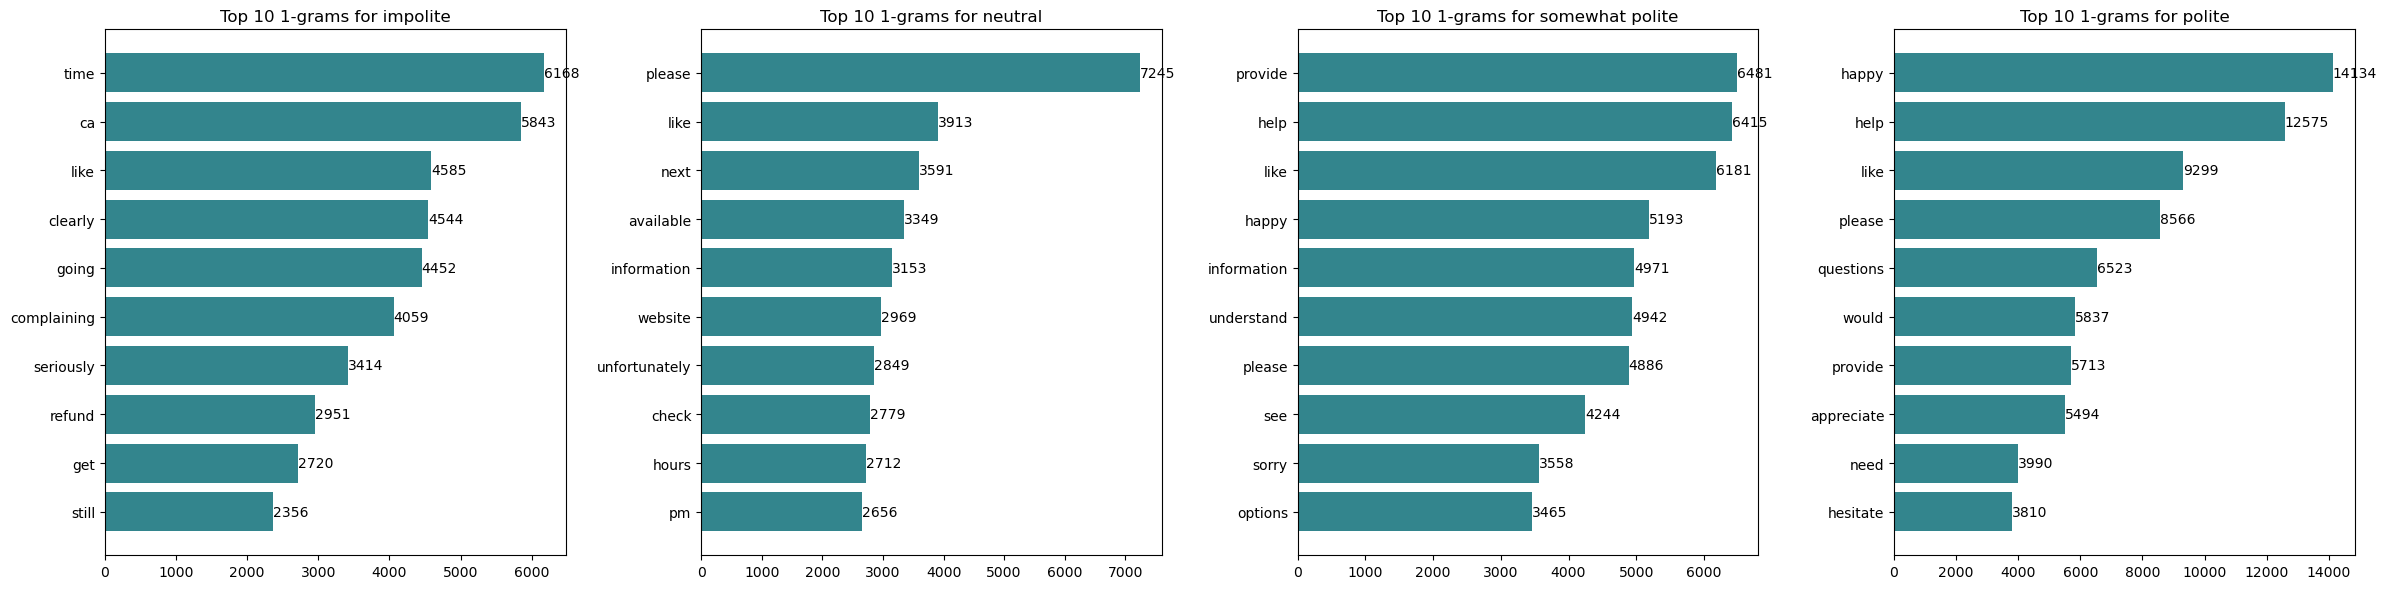

In [21]:
unigram_fig = plot_top_ngrams(label_texts, label_order, n=1, top_k=10)
plt.show()

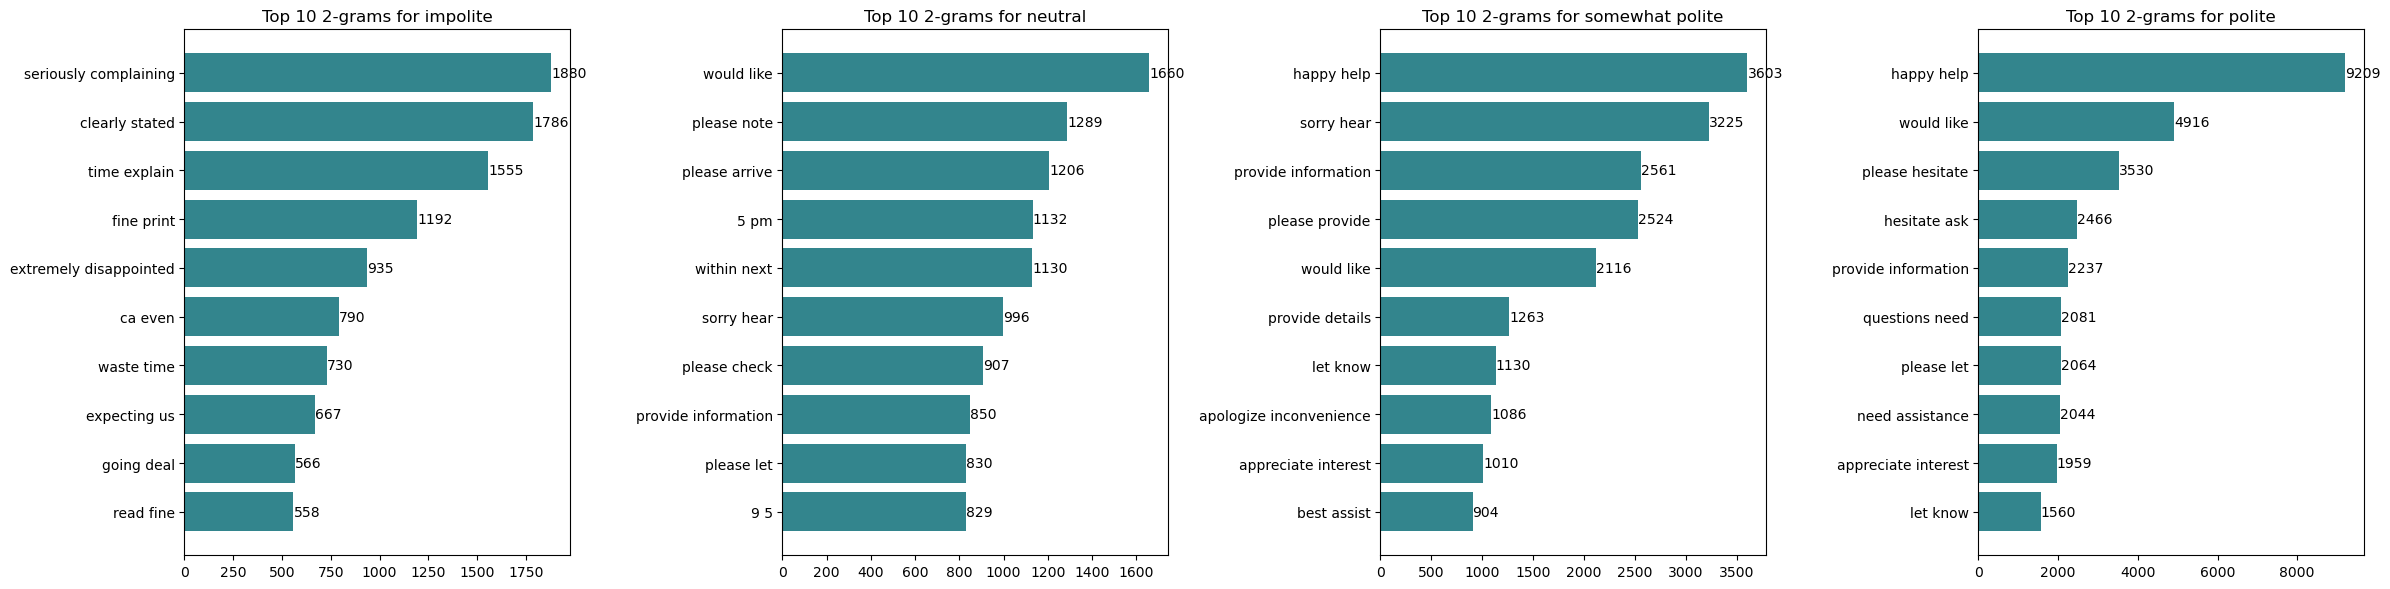

In [22]:
unigram_fig = plot_top_ngrams(label_texts, label_order, n=2, top_k=10)
plt.show()

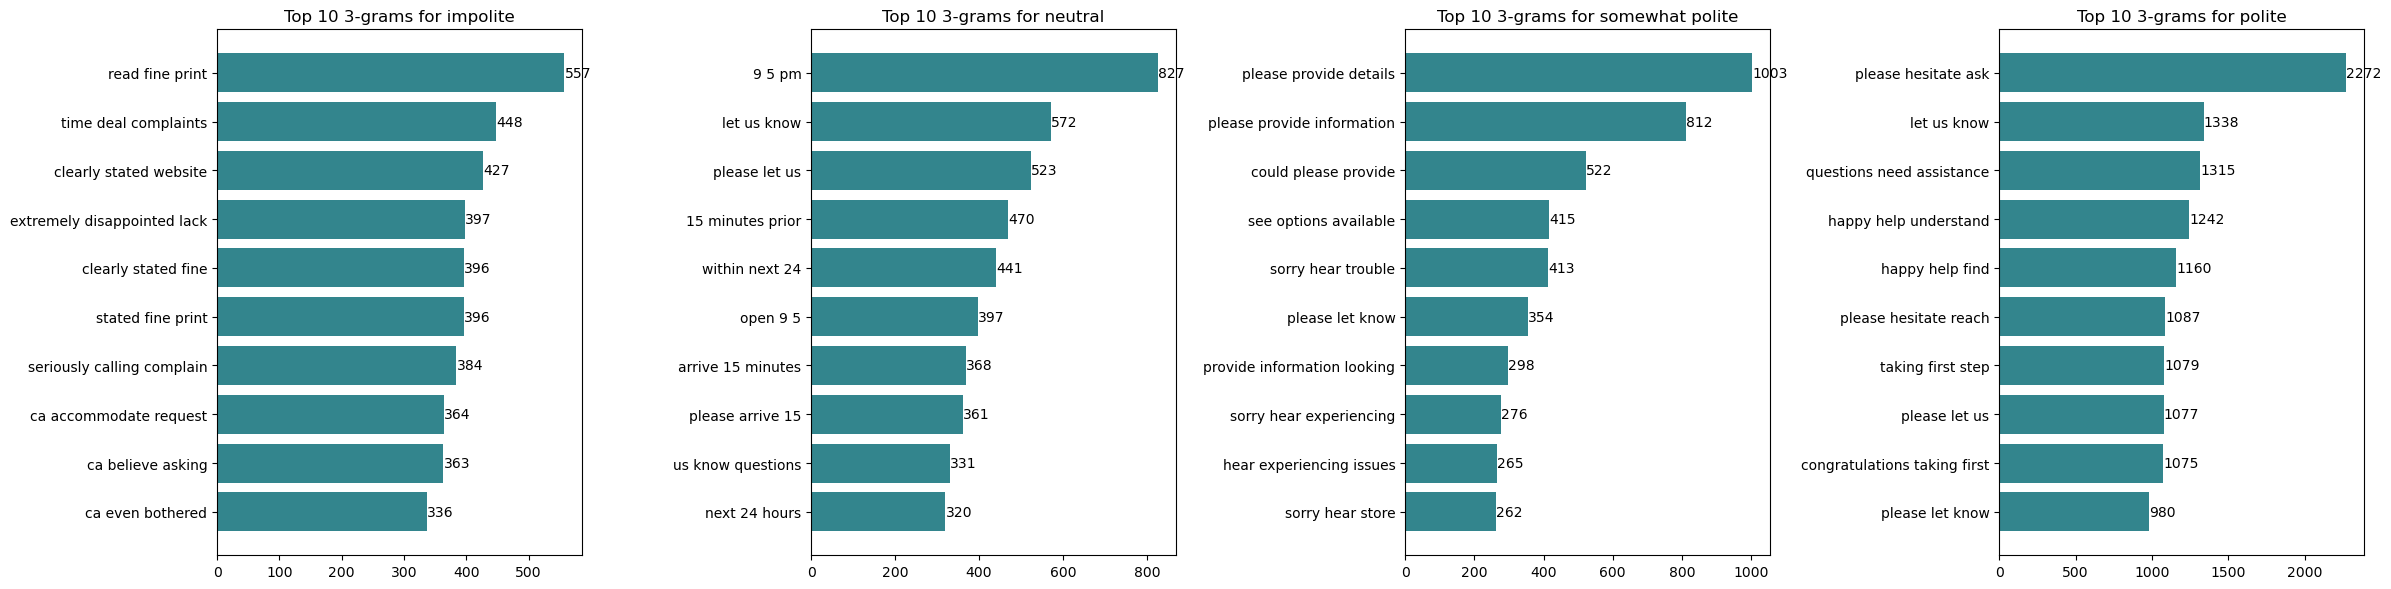

In [23]:
unigram_fig = plot_top_ngrams(label_texts, label_order, n=3, top_k=10)
plt.show()

In [24]:
def analyze_sentiment_subjectivity_for_plotting(df, label_order):
    sentiment_data_plot = {}
    for label in label_order:
        label_df = df[df['label'].astype(str) == label]['text'].dropna()
        polarities = []
        subjectivities = []
        for text in label_df:
            blob = TextBlob(text)
            polarities.append(blob.sentiment.polarity)
            subjectivities.append(blob.sentiment.subjectivity)
        sentiment_data_plot[label] = {'polarity': polarities, 'subjectivity': subjectivities}
    return sentiment_data_plot


In [25]:
def plot_combined_sentiment_analysis(sentiment_results, label_order):
    datasets = list(sentiment_results.keys())
    num_datasets = len(datasets)
    
    # Create grid: 2 rows (polarity/subjectivity) × N datasets
    fig, axes = plt.subplots(2, num_datasets, 
                           figsize=(4.5 * num_datasets, 8),
                           squeeze=False) 
    fig.suptitle('Sentiment Analysis Comparison', y=1.02)

    palette = sns.color_palette("crest", n_colors=len(label_order))

    for col_idx, dataset_name in enumerate(datasets):
        data = sentiment_results[dataset_name]
        
        polarity_data = []
        subjectivity_data = []
        plot_labels = []

        for label in label_order:
            if data.get(label):
                polarity_data.extend(data[label]['polarity'])
                subjectivity_data.extend(data[label]['subjectivity'])
                plot_labels.extend([label] * len(data[label]['polarity']))

        polarity_df = pd.DataFrame({'Label': plot_labels, 'Polarity': polarity_data})
        subjectivity_df = pd.DataFrame({'Label': plot_labels, 'Subjectivity': subjectivity_data})

        # --- Polarity Plot (Top Row) ---
        ax_pol = axes[0, col_idx]
        if not polarity_df.empty:
            sns.boxplot(x='Label', y='Polarity', data=polarity_df, 
                        hue='Label', palette=palette, width=0.6, 
                        order=label_order, ax=ax_pol, legend=False)
            ax_pol.set_title(f'{dataset_name}\nPolarity', fontsize=12)
            ax_pol.set_ylabel('Polarity Score')
            ax_pol.tick_params(axis='x', labelrotation=45)
            ax_pol.grid(True, alpha=0.3, axis='y')
        else:
            ax_pol.text(0.5, 0.5, "No polarity data", 
                       ha='center', va='center')
            ax_pol.axis('off')

        # --- Subjectivity Plot (Bottom Row) ---
        ax_sub = axes[1, col_idx]
        if not subjectivity_df.empty:
            sns.boxplot(x='Label', y='Subjectivity', data=subjectivity_df,
                        hue='Label', palette=palette, width=0.6,
                        order=label_order, ax=ax_sub, legend=False)
            ax_sub.set_title(f'{dataset_name}\nSubjectivity', fontsize=12)
            ax_sub.set_ylabel('Subjectivity Score')
            ax_sub.tick_params(axis='x', labelrotation=45)
            ax_sub.grid(True, alpha=0.3, axis='y')
        else:
            ax_sub.text(0.5, 0.5, "No subjectivity data",
                       ha='center', va='center')
            ax_sub.axis('off')

    plt.tight_layout()
    plt.show()

In [26]:
sentiment_plot_results = {}
for name, df in dataframes.items():
    if 'label' in df.columns and 'text' in df.columns:
        print(f"\nProcessing: {name}")
        sentiment_plot_results[name] = analyze_sentiment_subjectivity_for_plotting(df, label_order)


Processing: train_cot

Processing: train_few_shot

Processing: val_cot

Processing: val_few_shot

Processing: test_cot

Processing: test_few_shot

Processing: test_LMs


TypeError: Axes.boxplot() got an unexpected keyword argument 'legend'

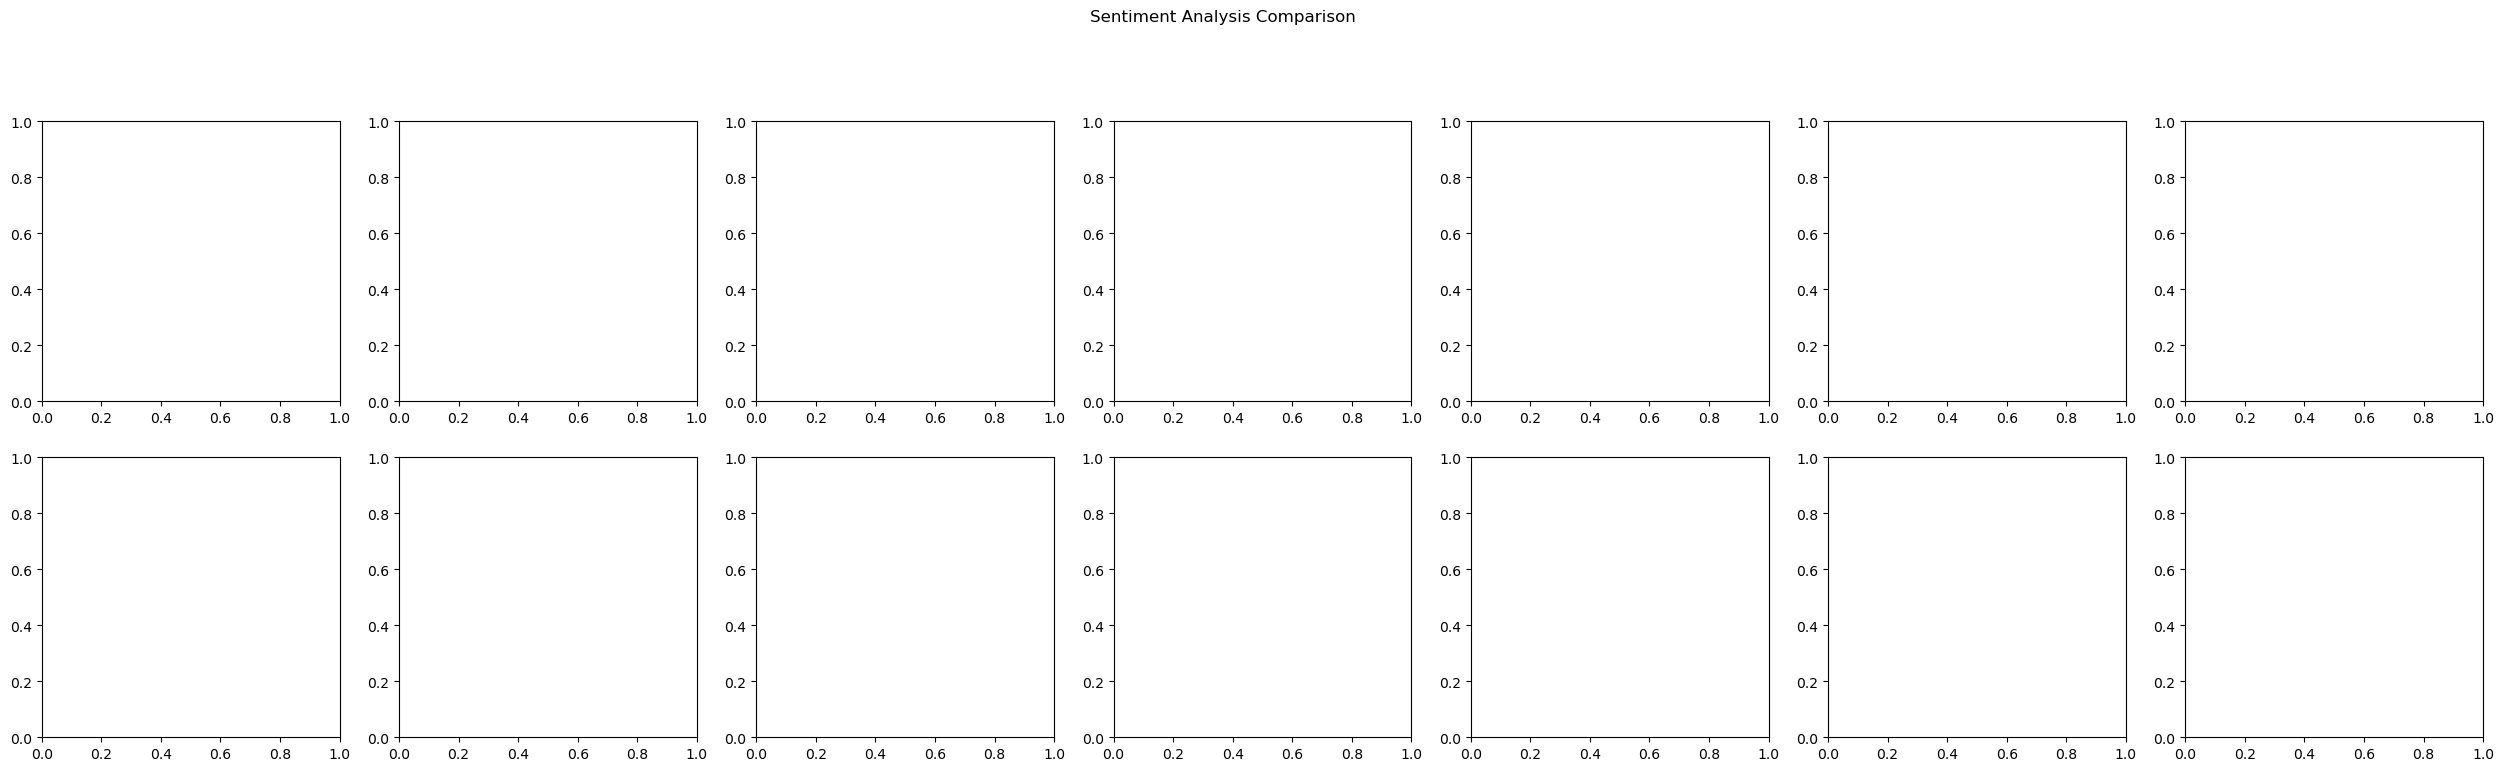

In [27]:
if sentiment_plot_results:
    plot_combined_sentiment_analysis(sentiment_plot_results, label_order)
else:
    print("No valid datasets found for sentiment analysis")

## Preprocessing and feature representation techniques
- case folding
- Tokenization, stemming, lemmatization
- stop words removal